<a href="https://colab.research.google.com/github/udekontee/GA4-Ecommerce-Analytics-Purchase-Prediction/blob/main/GA4_Ecommerce_Statistical_Analysis_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google GA4 Ecommerce Analytics & Purchase Prediction

## Project Overview

This project analyzes Google Analytics 4 (GA4) ecommerce data from the Google Merchandise Store to understand customer behavior, evaluate conversion patterns, and predict future purchases.

The project combines SQL, Python, statistical analysis, data visualization, feature engineering, and machine learning to move from raw ecommerce event data to actionable business insights.

### Business Questions

1. What does the ecommerce conversion funnel look like?
2. Do purchase patterns differ across device categories?
3. Do traffic sources differ in conversion performance?
4. How does user engagement differ between purchasers and non-purchasers?
5. Can earlier user behavior help predict future purchases?
6. Which machine learning model performs best for identifying users more likely to purchase?

### Tools Used

- Google BigQuery
- SQL
- Google Colab
- Python
- Pandas
- SciPy
- Scikit-learn
- Matplotlib

# 1. Data Source and Environment Setup

The analysis uses the public Google Analytics 4 ecommerce sample dataset available through Google BigQuery. The dataset contains obfuscated ecommerce event data from the Google Merchandise Store.

Google Colab is used as the primary analysis environment. BigQuery is accessed from within Colab to retrieve and aggregate the GA4 event data using SQL.

The following code authenticates the Colab environment so that it can connect to Google Cloud and query the public BigQuery dataset.

In [1]:
from google.colab import auth
auth.authenticate_user()

## 1.1 Connecting to BigQuery

After authenticating the Colab environment, the next step is to create a BigQuery client.

The BigQuery client allows SQL queries to be executed directly from this Colab notebook against Google's public GA4 ecommerce dataset.

In [2]:
from google.cloud import bigquery

project_id = "ga4-ecommerce-portfolio-508107"

client = bigquery.Client(project=project_id)

print("Connected to:", client.project)

Connected to: ga4-ecommerce-portfolio-508107


## 1.2 Data Source and Analysis Period

This project uses Google's public GA4 ecommerce sample dataset:

`bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`

The dataset contains obfuscated Google Analytics 4 event-level data from the Google Merchandise Store.

For this analysis, the available sample period covers approximately three months of ecommerce activity, from November 2020 through January 2021.

Before beginning the analysis, the dataset will be explored to understand its size, date coverage, user volume, and most common event types.

In [3]:
query = """
SELECT
  COUNT(*) AS event_count,
  COUNT(DISTINCT user_pseudo_id) AS user_count,
  COUNT(DISTINCT event_date) AS day_count,
  MIN(event_date) AS start_date,
  MAX(event_date) AS end_date
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
"""

dataset_summary = client.query(query).to_dataframe()

dataset_summary

,event_count,user_count,day_count,start_date,end_date
0,4295584,270154,92,20201101,20210131


### Dataset Summary

The GA4 sample contains **4,295,584 events** generated by **270,154 users** across **92 days**, covering **November 1, 2020 through January 31, 2021**.

This confirms the analysis period and provides the overall scale of the dataset before examining individual ecommerce events and customer behavior.

# 2. Exploratory Data Analysis (EDS)

Before analyzing the ecommerce conversion funnel, the GA4 event data was explored to understand the most common types of user activity recorded on the website.

## 2.1 Event Distribution

GA4 records user interactions as events. Examining the frequency of these events provides an overview of customer activity and helps identify the events that are most relevant to the ecommerce purchase journey.

The following query counts each event type and ranks them from most to least frequent.

In [4]:
query = """
SELECT
  event_name,
  COUNT(*) AS event_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
GROUP BY event_name
ORDER BY event_count DESC
"""

event_summary = client.query(query).to_dataframe()

event_summary.head(15)

,event_name,event_count
0,page_view,1350428
1,user_engagement,1058721
2,scroll,493072
3,view_item,386068
4,session_start,354970
5,first_visit,257462
6,view_promotion,190104
7,add_to_cart,58543
8,begin_checkout,38757
9,select_item,31007


### Key Finding

General browsing and engagement events occur much more frequently than purchase events. `page_view` is the most common event with 1,350,428 occurrences, followed by `user_engagement` with 1,058,721.

Within the ecommerce journey, 386,068 `view_item` events were recorded, compared with 58,543 `add_to_cart` events, 38,757 `begin_checkout` events, and 5,692 `purchase` events.

The substantial decline in event counts as users move toward purchase suggests that the ecommerce funnel should be examined more closely to identify where the largest drop-offs occur.

## 2.2 Key Ecommerce Events

The exploratory analysis identified several events that represent important stages of the customer purchase journey.

For the main funnel analysis, four events are used:

**View Item → Add to Cart → Begin Checkout → Purchase**

These events provide a simplified view of how customer activity decreases as users progress toward completing a purchase.

# 3. Ecommerce Funnel Analysis

The ecommerce funnel shows how customer activity changes as users move from viewing a product toward completing a purchase.

The four major funnel stages analyzed are:

**View Item → Add to Cart → Begin Checkout → Purchase**

Analyzing the number of events at each stage helps identify where the largest drop-offs occur in the purchase journey.

## 3.1 Funnel Event Counts

The following query calculates the number of events recorded at each major stage of the ecommerce funnel.

In [6]:
query = """
SELECT
  event_name,
  COUNT(*) AS event_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name IN (
  'view_item',
  'add_to_cart',
  'begin_checkout',
  'purchase'
)
GROUP BY event_name
"""

funnel = client.query(query).to_dataframe()

import pandas as pd
funnel_order = [
    "view_item",
    "add_to_cart",
    "begin_checkout",
    "purchase"
]

funnel["event_name"] = pd.Categorical(
    funnel["event_name"],
    categories=funnel_order,
    ordered=True
)

funnel = funnel.sort_values("event_name").reset_index(drop=True)

funnel

,event_name,event_count
0,view_item,386068
1,add_to_cart,58543
2,begin_checkout,38757
3,purchase,5692


## 3.2 Funnel Conversion and Drop-Off Rates

Raw event counts show that activity decreases substantially as customers move through the purchase journey. To better understand where customers leave the funnel, conversion and drop-off rates are calculated between consecutive stages.

The conversion rate measures the percentage of activity that progresses from one funnel stage to the next, while the drop-off rate represents the percentage that does not continue to the next stage.

Because this analysis uses event counts rather than uniquely tracked user journeys, these percentages should be interpreted as event-level funnel indicators rather than exact user-level conversion probabilities.

In [7]:
funnel["conversion_from_previous_pct"] = (
    funnel["event_count"]
    .div(funnel["event_count"].shift(1))
    .mul(100)
    .round(2)
)

funnel["dropoff_from_previous_pct"] = (
    100 - funnel["conversion_from_previous_pct"]
).round(2)

funnel

,event_name,event_count,conversion_from_previous_pct,dropoff_from_previous_pct
0,view_item,386068,<NA>,<NA>
1,add_to_cart,58543,15.16,84.84
2,begin_checkout,38757,66.2,33.8
3,purchase,5692,14.69,85.31


### Key Finding

The ecommerce funnel shows substantial drop-off as activity progresses toward purchase.

- Only **15.16%** of product-view events progress to an add-to-cart event, representing an **84.84% drop-off**.
- From add-to-cart to begin-checkout, the funnel performs considerably better, with a **66.20% conversion rate** and **33.80% drop-off**.
- The largest late-stage challenge occurs between begin-checkout and purchase. Only **14.69%** of checkout events correspond to purchases, representing an **85.31% drop-off**.

The results suggest that the strongest opportunities for further investigation are the **product-view-to-cart stage** and particularly the **checkout-to-purchase stage**.

Because these calculations are based on event counts rather than individual user journeys, they should be interpreted as exploratory funnel indicators rather than exact user-level conversion rates.

## 3.3 Ecommerce Funnel Visualization

The funnel event counts are visualized to make the decline in activity across the four purchase stages easier to compare.

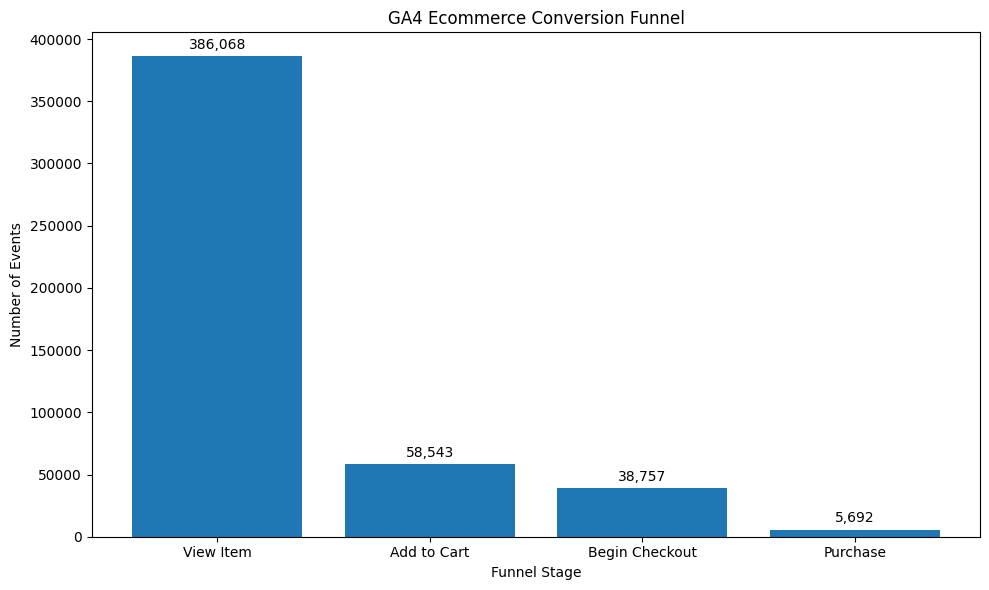

In [8]:
import matplotlib.pyplot as plt

funnel_plot = funnel.copy()

funnel_plot["stage"] = [
    "View Item",
    "Add to Cart",
    "Begin Checkout",
    "Purchase"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    funnel_plot["stage"],
    funnel_plot["event_count"]
)

plt.title("GA4 Ecommerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Events")

plt.bar_label(
    bars,
    labels=[f"{x:,}" for x in funnel_plot["event_count"]],
    padding=3
)

plt.tight_layout()
plt.show()

### Funnel Interpretation

The visualization shows a steep decline in event activity across the ecommerce journey. Product views are substantially more common than add-to-cart events, while purchases represent only a small fraction of the activity observed at the beginning of the funnel.

The strongest event-level drop-offs occur between **View Item and Add to Cart** and between **Begin Checkout and Purchase**. These stages represent important areas for further investigation into potential barriers in the customer purchase journey.

Because the funnel is based on aggregate event counts rather than individual user paths, the results describe overall funnel activity and should not be interpreted as exact user-level conversion probabilities.

# 4. Device Analysis

Device type may influence how customers interact with an ecommerce website. This section compares product-view and purchase activity across desktop, mobile, and tablet users.

## 4.1 Purchase Activity by Device

The analysis compares the number of purchase events and non-purchase product-view events across device categories.

The goal is to determine whether some devices show higher purchase activity relative to product viewing.

In [9]:
query = """
SELECT
  device.category AS device_category,
  COUNTIF(event_name = 'purchase') AS purchase,
  COUNTIF(event_name = 'view_item') -
    COUNTIF(event_name = 'purchase') AS no_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name IN ('view_item', 'purchase')
GROUP BY device_category
ORDER BY device_category
"""

device_summary = client.query(query).to_dataframe()

device_summary

,device_category,purchase,no_purchase
0,desktop,3226,221811
1,mobile,2355,150321
2,tablet,111,8244


## 4.2 Purchase Rate by Device

Raw purchase counts are useful, but they can be misleading when device categories have different levels of activity.

To make the comparison more meaningful, the purchase rate is calculated as the share of purchase events relative to the combined total of purchase and non-purchase product-view events for each device category.

In [10]:
device_summary["total"] = (
    device_summary["purchase"] +
    device_summary["no_purchase"]
)

device_summary["purchase_rate_pct"] = (
    device_summary["purchase"]
    .div(device_summary["total"])
    .mul(100)
    .round(2)
)

device_summary

,device_category,purchase,no_purchase,total,purchase_rate_pct
0,desktop,3226,221811,225037,1.43
1,mobile,2355,150321,152676,1.54
2,tablet,111,8244,8355,1.33


### Key Finding

Purchase rates are relatively similar across the three device categories.

- **Mobile:** 1.54%
- **Desktop:** 1.43%
- **Tablet:** 1.33%

Mobile shows the highest purchase rate, but the differences between device categories are small. Based on the descriptive results alone, device type does not appear to produce a large difference in purchase behavior.

A statistical test will be conducted later to determine whether the observed differences are statistically significant and to measure the strength of the association.


## 4.3 Device Purchase Rate Visualization

Purchase rates are visualized across device categories to make the differences between desktop, mobile, and tablet activity easier to compare.

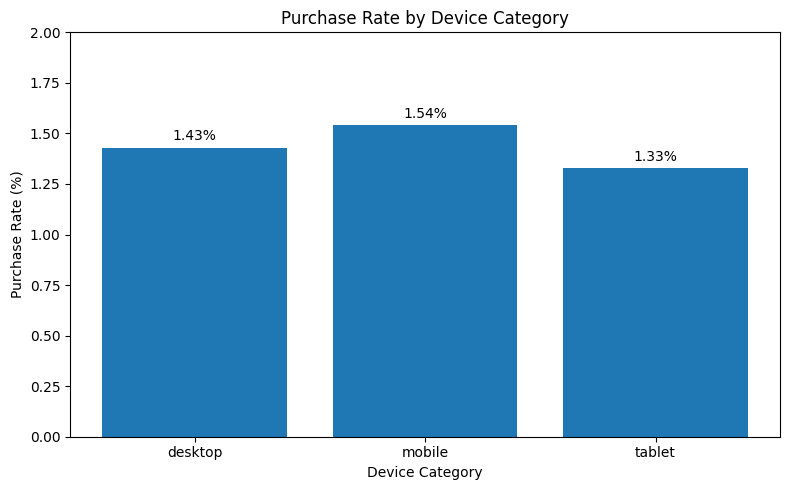

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    device_summary["device_category"],
    device_summary["purchase_rate_pct"]
)

plt.title("Purchase Rate by Device Category")
plt.xlabel("Device Category")
plt.ylabel("Purchase Rate (%)")

plt.bar_label(
    bars,
    labels=[
        f"{x:.2f}%"
        for x in device_summary["purchase_rate_pct"]
    ],
    padding=3
)

plt.ylim(0, 2)
plt.tight_layout()
plt.show()

### Device Analysis Interpretation

Mobile has the highest observed purchase rate at 1.54%, followed by desktop at 1.43% and tablet at 1.33%.

Although mobile performs slightly better, the differences across device categories are relatively small. The descriptive analysis therefore does not suggest a strong practical difference in purchase behavior by device.

Later statistical testing will determine whether the observed differences are statistically significant and whether the relationship is large enough to be practically meaningful.

# 5. Traffic Source Analysis

Traffic sources show how users arrived at the ecommerce website. Comparing purchase activity across traffic sources can help identify whether some acquisition channels are associated with higher purchase rates.

## 5.1 Purchase Activity by Traffic Source

The following analysis compares purchase and non-purchase product-view activity across the major traffic sources.

Traffic sources with fewer than 100 product-view events are excluded to reduce the influence of very small categories.

In [12]:
query_traffic = """
SELECT
  traffic_source.source AS traffic_source,
  COUNTIF(event_name = 'purchase') AS purchase,
  COUNTIF(event_name = 'view_item') -
    COUNTIF(event_name = 'purchase') AS no_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name IN ('view_item', 'purchase')
GROUP BY traffic_source
HAVING COUNTIF(event_name = 'view_item') >= 100
ORDER BY traffic_source
"""

traffic_summary = client.query(query_traffic).to_dataframe()

traffic_summary

,traffic_source,purchase,no_purchase
0,(data deleted),830,31895
1,(direct),1251,86665
2,<Other>,1290,96971
3,google,1620,130128
4,shop.googlemerchandisestore.com,701,34717


## 5.2 Purchase Rate by Traffic Source

Raw purchase counts do not account for differences in traffic volume across acquisition sources.

To make the sources more comparable, the purchase rate is calculated as the share of purchase events relative to the combined total of purchase and non-purchase product-view events for each traffic source.

In [13]:
traffic_summary["total"] = (
    traffic_summary["purchase"] +
    traffic_summary["no_purchase"]
)

traffic_summary["purchase_rate_pct"] = (
    traffic_summary["purchase"]
    .div(traffic_summary["total"])
    .mul(100)
    .round(2)
)

traffic_summary = traffic_summary.sort_values(
    "purchase_rate_pct",
    ascending=False
).reset_index(drop=True)

traffic_summary

,traffic_source,purchase,no_purchase,total,purchase_rate_pct
0,(data deleted),830,31895,32725,2.54
1,shop.googlemerchandisestore.com,701,34717,35418,1.98
2,(direct),1251,86665,87916,1.42
3,<Other>,1290,96971,98261,1.31
4,google,1620,130128,131748,1.23


### Key Finding

Purchase rates vary more across traffic sources than across device categories.

- **(data deleted): 2.54%**
- **shop.googlemerchandisestore.com: 1.98%**
- **(direct): 1.42%**
- **<Other>: 1.31%**
- **google: 1.23%**

The `(data deleted)` category has the highest observed purchase rate, although its source information is unavailable and therefore cannot be interpreted as a specific acquisition channel.

Among identifiable sources, `shop.googlemerchandisestore.com` has the highest purchase rate at 1.98%, while Google has the lowest at 1.23%.

These descriptive differences suggest that traffic source may have a stronger relationship with purchase activity than device category. Statistical testing will be used later to evaluate the strength of this association.

## 5.3 Traffic Source Purchase Rate Visualization

Purchase rates are visualized across traffic sources to make differences in conversion activity easier to compare.

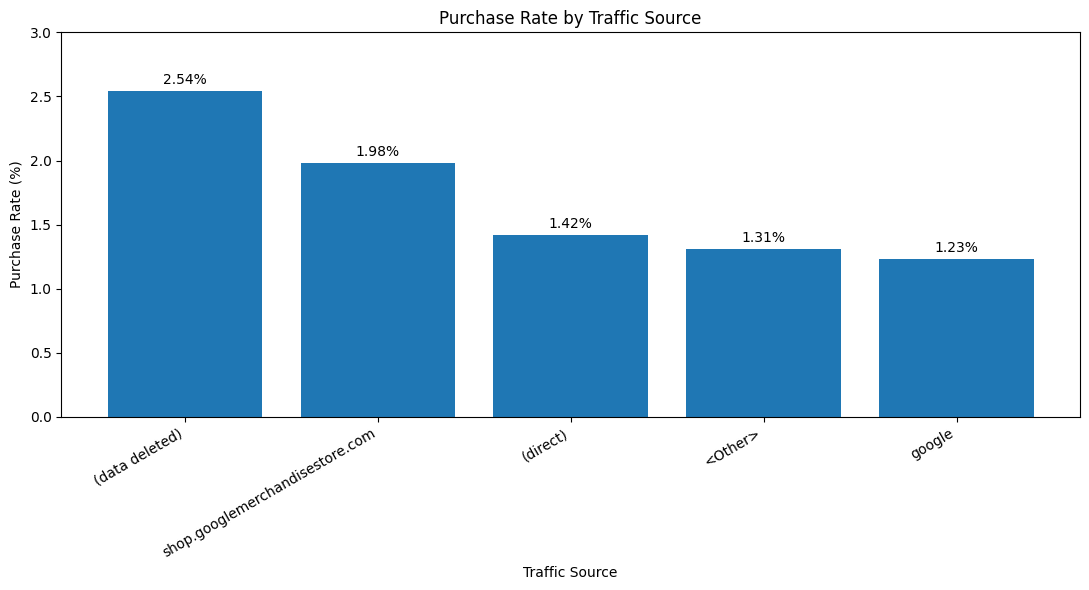

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

bars = plt.bar(
    traffic_summary["traffic_source"],
    traffic_summary["purchase_rate_pct"]
)

plt.title("Purchase Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Purchase Rate (%)")

plt.bar_label(
    bars,
    labels=[
        f"{x:.2f}%"
        for x in traffic_summary["purchase_rate_pct"]
    ],
    padding=3
)

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 3)
plt.tight_layout()
plt.show()

### Interpretation

Purchase rates vary across traffic sources. The `(data deleted)` category has the highest observed purchase rate at 2.54%, although the source cannot be identified. Among identifiable sources, `shop.googlemerchandisestore.com` has the highest purchase rate at 1.98%, followed by `(direct)` at 1.42%, `<Other>` at 1.31%, and `google` at 1.23%.

The differences are larger than those observed across device categories, suggesting that traffic source may have a stronger relationship with purchase activity. However, descriptive differences alone do not establish statistical significance or the strength of the relationship.

The next section uses Chi-Square tests and Cramér's V to evaluate these relationships statistically.

# 6. Statistical Testing

Descriptive analysis showed differences in purchase rates across device categories and traffic sources. Statistical testing is used to determine whether these observed differences provide evidence of an association with purchase activity.

The Chi-Square Test of Independence evaluates whether two categorical variables are associated.

Cramér's V is then used to measure the strength of that association.

## 6.1 Device Category vs Purchase

**Null Hypothesis (H₀):** Device category and purchase activity are independent.

**Alternative Hypothesis (H₁):** Device category and purchase activity are associated.

A significance level of 0.05 is used.

In [ ]:
class_weight="balanced"

In [17]:
from scipy.stats import chi2_contingency
import numpy as np

# Create contingency table
observed_device = device_summary[
    ["purchase", "no_purchase"]
].astype("int64")

# Chi-Square Test
chi2_device, p_device, dof_device, expected_device = (
    chi2_contingency(observed_device)
)

# Cramér's V
n = observed_device.to_numpy().sum()
rows, cols = observed_device.shape

cramers_v_device = np.sqrt(
    chi2_device / (n * min(rows - 1, cols - 1))
)

print("Chi-Square:", chi2_device)
print("P-value:", p_device)
print("Degrees of Freedom:", dof_device)
print("Cramér's V:", cramers_v_device)

Chi-Square: 8.681514640031262
P-value: 0.013026659117194896
Degrees of Freedom: 2
Cramér's V: 0.0047420469343951695


### Interpretation

The Chi-Square test produced a p-value of approximately **0.013**, which is below the 0.05 significance level. Therefore, the null hypothesis is rejected, providing statistical evidence of an association between device category and purchase activity.

However, **Cramér's V is approximately 0.0047**, indicating that the strength of the association is extremely weak.

This means that although purchase activity differs statistically across desktop, mobile, and tablet devices, the practical relationship between device category and purchase activity is negligible.

Therefore, device category alone is unlikely to be a strong factor for explaining purchase behavior in this dataset.

**Note:** This is an exploratory event-level analysis. Because individual users may generate multiple events, the observations may not be fully independent.

## 6.2 Traffic Source vs Purchase

The Chi-Square Test of Independence is used to determine whether traffic source and purchase activity are statistically associated.

**Null Hypothesis (H₀):** Traffic source and purchase activity are independent.

**Alternative Hypothesis (H₁):** Traffic source and purchase activity are associated.

A significance level of 0.05 is used. Cramér's V is also calculated to measure the strength of the association.

In [18]:
# Create contingency table
observed_traffic = traffic_summary[
    ["purchase", "no_purchase"]
].astype("int64")

# Chi-Square Test
chi2_traffic, p_traffic, dof_traffic, expected_traffic = (
    chi2_contingency(observed_traffic)
)

# Cramér's V
n = observed_traffic.to_numpy().sum()
rows, cols = observed_traffic.shape

cramers_v_traffic = np.sqrt(
    chi2_traffic / (n * min(rows - 1, cols - 1))
)

print("Chi-Square:", chi2_traffic)
print("P-value:", p_traffic)
print("Degrees of Freedom:", dof_traffic)
print("Cramér's V:", cramers_v_traffic)

Chi-Square: 389.7707280373607
P-value: 4.511944937227775e-83
Degrees of Freedom: 4
Cramér's V: 0.03177405970440271


### Interpretation

The Chi-Square test produced an extremely small p-value (approximately **4.51 × 10⁻⁸³**), which is far below the 0.05 significance level. Therefore, the null hypothesis is rejected, providing statistical evidence of an association between traffic source and purchase activity.

Cramér's V is approximately **0.0318**, indicating that the association is still weak in practical terms.

However, the relationship between traffic source and purchase activity is stronger than the relationship observed for device category, where Cramér's V was only 0.0047.

This suggests that traffic source may provide more useful information about purchase behavior than device category, although neither variable shows a strong association on its own.

**Note:** This is an exploratory event-level analysis. Because individual users may generate multiple events, the observations may not be fully independent.

# 7. User Engagement Analysis

The previous sections examined purchase activity across device categories and traffic sources. This section shifts the analysis to user behavior.

The goal is to determine whether users who purchased products showed different levels of engagement compared with users who did not purchase.

Three behavioral measures are examined:

- Engagement events
- Page views
- Product views

For this descriptive analysis, users are grouped according to whether they generated at least one purchase event during the analysis period.

## 7.1 User-Level Engagement Data

GA4 event data is aggregated to the user level using `user_pseudo_id`. Each row in the resulting dataset represents one user and summarizes that user's activity during the analysis period.

In [19]:
query_engagement = """
SELECT
  user_pseudo_id,

  COUNTIF(event_name = 'user_engagement') AS engagement_events,

  COUNTIF(event_name = 'page_view') AS page_views,

  COUNTIF(event_name = 'view_item') AS product_views,

  MAX(
    CASE
      WHEN event_name = 'purchase' THEN 1
      ELSE 0
    END
  ) AS purchased

FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`

GROUP BY user_pseudo_id
"""

engagement_summary = client.query(query_engagement).to_dataframe()

engagement_summary.head()

,user_pseudo_id,engagement_events,page_views,product_views,purchased
0,1298332.8805790276,73,84,38,1
1,2364862.0108372853,45,47,12,1
2,3336646.4974569457,79,87,41,1
3,3875096.2744239318,48,56,31,0
4,4130336.2522893697,13,13,0,0


## 7.2 Comparing Purchasers and Non-Purchasers

To examine differences in user behavior, average engagement metrics are calculated separately for purchasers and non-purchasers.

This comparison helps determine whether users who purchase tend to generate more engagement events, page views, and product views than users who do not purchase.

In [20]:
engagement_means = (
    engagement_summary
    .groupby("purchased")[
        ["engagement_events", "page_views", "product_views"]
    ]
    .mean()
    .round(2)
)

engagement_means

,engagement_events,page_views,product_views
purchased,,,
0,3.2,4.22,1.08
1,47.4,51.67,22.63


## 7.3 Median Engagement Comparison

Because ecommerce engagement data can be skewed by highly active users, median values are also compared.

The median provides a useful measure of typical user behavior and is less affected by extreme values than the mean.

In [21]:
engagement_medians = (
    engagement_summary
    .groupby("purchased")[
        ["engagement_events", "page_views", "product_views"]
    ]
    .median()
)

engagement_medians

,engagement_events,page_views,product_views
purchased,,,
0,1.0,2.0,0.0
1,36.0,40.0,15.0


### Interpretation

Purchasers show substantially higher engagement than non-purchasers across all three behavioral measures.

For non-purchasers, the median user generated only **1 engagement event, 2 page views, and 0 product views**. In comparison, purchasers generated medians of **36 engagement events, 40 page views, and 15 product views**.

The mean values show the same pattern, with purchasers averaging **47.40 engagement events, 51.67 page views, and 22.63 product views**, compared with only **3.20, 4.22, and 1.08** for non-purchasers.

Together, the mean and median results show a strong descriptive relationship between higher user engagement and purchase activity.

However, these measures were collected during the same period as the purchase outcome. Therefore, they should not yet be interpreted as predictors of future purchases. The next section separates earlier user behavior from future purchase activity to prevent data leakage.

## 7.4 Average Engagement by Purchase Status

The average engagement measures are visualized to show the behavioral differences between purchasers and non-purchasers.

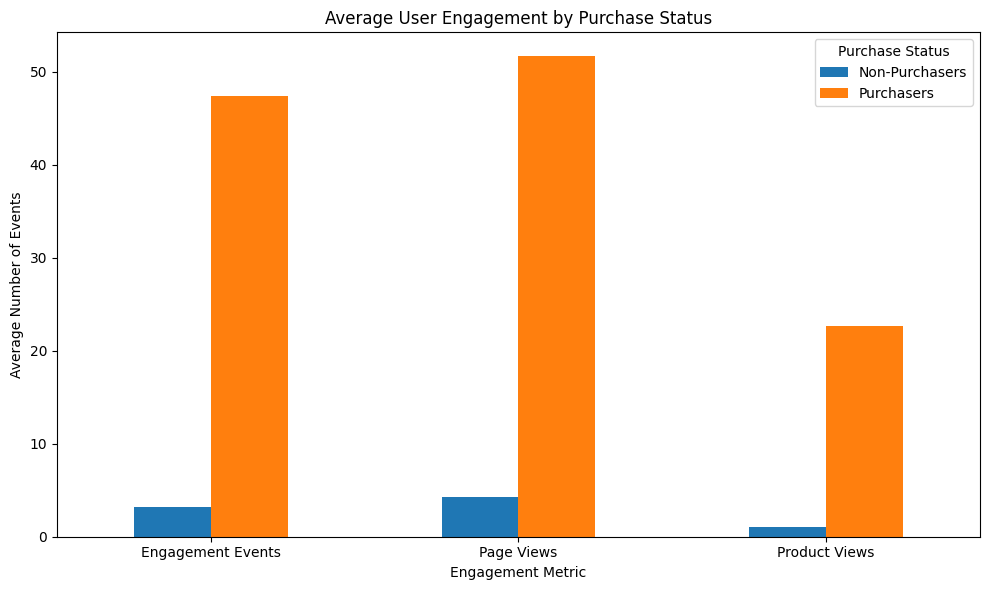

In [22]:
engagement_plot = engagement_means.T

engagement_plot.columns = [
    "Non-Purchasers",
    "Purchasers"
]

engagement_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average User Engagement by Purchase Status")
plt.xlabel("Engagement Metric")
plt.ylabel("Average Number of Events")
plt.xticks(
    ticks=range(3),
    labels=[
        "Engagement Events",
        "Page Views",
        "Product Views"
    ],
    rotation=0
)
plt.legend(title="Purchase Status")
plt.tight_layout()
plt.show()

### Visualization Interpretation

The visualization shows a substantial difference in average engagement between purchasers and non-purchasers.

Purchasers generated considerably more engagement events, page views, and product views than non-purchasers. The largest differences are visible in page views and engagement events, while product views also show a clear separation between the two groups.

These results indicate a strong descriptive relationship between user engagement and purchase activity. However, because the engagement measures and purchase outcome were observed during the same period, this analysis does not establish that the engagement measures can predict future purchases.

To build a valid predictive model, earlier user behavior must be separated from future purchase activity.

# 8. Feature Engineering and Leakage Prevention

The engagement analysis showed that purchasers were substantially more active than non-purchasers. However, using engagement behavior from the same period as the purchase outcome could introduce data leakage.

To create a more realistic prediction problem, the dataset is divided into two time periods:

- **Feature period:** November 1, 2020 through December 30, 2020
- **Prediction period:** December 31, 2020 through January 31, 2021

Engagement behavior from the earlier period is used as the model input, while purchase activity from the later period becomes the target.

This ensures that the model uses earlier behavior to predict a future outcome rather than using information observed during the outcome period.

In [23]:
query_model = """
WITH features AS (
    SELECT
        user_pseudo_id,
        COUNTIF(event_name = 'user_engagement') AS engagement_events,
        COUNTIF(event_name = 'page_view') AS page_views,
        COUNTIF(event_name = 'view_item') AS product_views
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201230'
    GROUP BY user_pseudo_id
),

future_purchase AS (
    SELECT
        user_pseudo_id,
        MAX(
            CASE
                WHEN event_name = 'purchase' THEN 1
                ELSE 0
            END
        ) AS purchased
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201231' AND '20210131'
    GROUP BY user_pseudo_id
)

SELECT
    f.user_pseudo_id,
    f.engagement_events,
    f.page_views,
    f.product_views,
    COALESCE(p.purchased, 0) AS purchased
FROM features AS f
LEFT JOIN future_purchase AS p
    USING (user_pseudo_id)
"""

model_data = client.query(query_model).to_dataframe()

print("Dataset shape:", model_data.shape)
model_data.head()

Dataset shape: (176942, 5)


,user_pseudo_id,engagement_events,page_views,product_views,purchased
0,1021887.1151788384,15,15,6,0
1,5320068.3830223799,33,53,11,0
2,5798842.3922639602,137,143,105,0
3,6604560.8893864486,35,40,16,0
4,6624764.2030956955,20,22,4,0


## 8.2 Target Class Distribution

Before training the machine learning models, the distribution of the target variable is examined.

A highly imbalanced target can affect model training and evaluation because the model may favor the majority class. Understanding the class distribution will help determine the appropriate modeling and evaluation strategy.

- **0 = No purchase during the future prediction period**
- **1 = Purchase during the future prediction period**

In [24]:
class_counts = model_data["purchased"].value_counts().sort_index()

class_percentages = (
    model_data["purchased"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})

class_distribution

,count,percentage
purchased,,
0,176684,99.85
1,258,0.15


### Interpretation

The target variable is extremely imbalanced. Only **258 users (0.15%)** made a purchase during the future prediction period, while **176,684 users (99.85%)** did not.

Because the positive class is so rare, overall accuracy would be misleading. A model could achieve approximately 99.85% accuracy by predicting that every user will not purchase.

Therefore, model evaluation will focus on metrics that are more informative for rare-event prediction, including:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Class weighting will also be used to help the model give more attention to the rare purchaser class.

# 9. Machine Learning Model Development

The time-separated dataset is now used to build models that predict whether a user will make a purchase during the future prediction period.

The prediction target is binary:

- **0 = No future purchase**
- **1 = Future purchase**

The predictor variables are earlier user behaviors:

- Engagement events
- Page views
- Product views

Logistic Regression is used as the first model because it provides a strong and interpretable baseline for binary classification.

In [25]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "engagement_events",
    "page_views",
    "product_views"
]

X = model_data[feature_cols]
y = model_data["purchased"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

Training set: (141553, 3)
Test set: (35389, 3)

Training target:
purchased
0    141347
1       206
Name: count, dtype: int64

Test target:
purchased
0    35337
1       52
Name: count, dtype: int64


## 9.2 Logistic Regression Model

A Logistic Regression model is trained as the baseline classification model.

Because the target variable is extremely imbalanced, `class_weight="balanced"` is used so that the rare purchaser class receives greater importance during training.

The model is built in a pipeline with `StandardScaler`, which standardizes the engagement features before Logistic Regression is applied.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)
y_proba_log = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [27]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

logistic_metrics = {
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1-Score": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_proba_log),
    "PR-AUC": average_precision_score(y_test, y_proba_log)
}

logistic_metrics

{'Precision': 0.011773100249732429,
 'Recall': 0.6346153846153846,
 'F1-Score': 0.023117338003502626,
 'ROC-AUC': np.float64(0.887988945994719),
 'PR-AUC': np.float64(0.019691817678959736)}

### Logistic Regression Interpretation

The Logistic Regression model achieved:

- **Precision:** 0.0118 (1.18%)
- **Recall:** 0.6346 (63.46%)
- **F1-score:** 0.0231
- **ROC-AUC:** 0.8880
- **PR-AUC:** 0.0197

The model identified approximately **63% of the actual future purchasers**, demonstrating relatively strong recall.

However, precision is very low at approximately **1.18%**, meaning that many users predicted as potential purchasers were actually non-purchasers. This is expected to be challenging because future purchasers represent only 0.15% of the dataset.

The ROC-AUC of approximately **0.89** indicates that the model has good ability to rank purchasers above non-purchasers across different classification thresholds. However, ROC-AUC should not be interpreted as 89% accuracy.

The PR-AUC of approximately **0.0197** is low in absolute terms, but it is higher than the underlying positive-class rate of approximately 0.0015 (0.15%). This suggests that the model provides some useful ranking information despite the severe class imbalance.

Overall, Logistic Regression may be more useful as a tool for prioritizing higher-probability users for further analysis or targeted marketing rather than as a definitive yes-or-no purchase predictor.

## 9.4 Random Forest Model

A Random Forest Classifier is trained as a second machine learning model.

Unlike Logistic Regression, Random Forest can capture more complex and nonlinear relationships between user engagement behavior and future purchase activity.

Because the target is extremely imbalanced, `class_weight="balanced"` is used to give greater importance to the rare purchaser class.

The Random Forest will be evaluated using the same metrics as Logistic Regression so that the two models can be compared fairly.


In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 9.5 Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression: precision, recall, F1-score, ROC-AUC, and PR-AUC.

Using the same evaluation metrics allows the two models to be compared consistently, particularly because the target variable is extremely imbalanced.

In [29]:
rf_metrics = {
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf),
    "PR-AUC": average_precision_score(y_test, y_proba_rf)
}

rf_metrics

{'Precision': 0.0006273525721455458,
 'Recall': 0.019230769230769232,
 'F1-Score': 0.001215066828675577,
 'ROC-AUC': np.float64(0.3472305667844338),
 'PR-AUC': np.float64(0.001307865805769926)}

### Random Forest Interpretation

The Random Forest model achieved:

- **Precision:** 0.0006 (0.06%)
- **Recall:** 0.0192 (1.92%)
- **F1-score:** 0.0012
- **ROC-AUC:** 0.3472
- **PR-AUC:** 0.0013

The Random Forest performed poorly at identifying future purchasers. It detected only about **1.92% of the actual purchasers**, as shown by its very low recall.

Its ROC-AUC of approximately **0.35** indicates poor ability to distinguish purchasers from non-purchasers. The PR-AUC is also extremely low, which is particularly important given the severe class imbalance.

Although Random Forest is a more complex model than Logistic Regression, greater model complexity does not automatically result in better predictive performance.

For this dataset and feature set, Logistic Regression provides substantially better predictive performance than Random Forest.

# 10. Model Evaluation and Comparison

The Logistic Regression and Random Forest models are compared using the same evaluation metrics.

Because future purchasers represent only a very small percentage of users, accuracy could be misleading. Therefore, the comparison focuses on precision, recall, F1-score, ROC-AUC, and PR-AUC.

The objective is to determine which model provides the strongest ability to identify and rank users who may make a future purchase.

In [30]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Logistic Regression": logistic_metrics,
    "Random Forest": rf_metrics
}).T

model_comparison.round(4)

,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression,0.0118,0.6346,0.0231,0.8880,0.0197
Random Forest,0.0006,0.0192,0.0012,0.3472,0.0013


## 10.2 Model Comparison Interpretation

Logistic Regression substantially outperformed Random Forest across all evaluation metrics.

Logistic Regression achieved a recall of **63.46%**, compared with only **1.92%** for Random Forest. This means Logistic Regression identified a much larger proportion of the actual future purchasers.

Logistic Regression also achieved a substantially higher **ROC-AUC of 0.8880**, compared with **0.3472** for Random Forest, indicating much stronger ability to rank purchasers above non-purchasers.

The **PR-AUC** results are especially important because the purchaser class is extremely rare. Logistic Regression achieved a PR-AUC of **0.0197**, while Random Forest achieved only **0.0013**.

Although Logistic Regression's precision remains low at **1.18%**, it performs considerably better than Random Forest and provides useful ranking information for identifying users who may be more likely to purchase.

Based on these results, **Logistic Regression is selected as the better-performing model for this project**.

## 10.3 ROC Curve Comparison

The ROC curve compares the ability of each model to distinguish between future purchasers and non-purchasers across different classification thresholds.

A model with stronger discrimination will have a curve farther above the diagonal reference line and a higher ROC-AUC score.

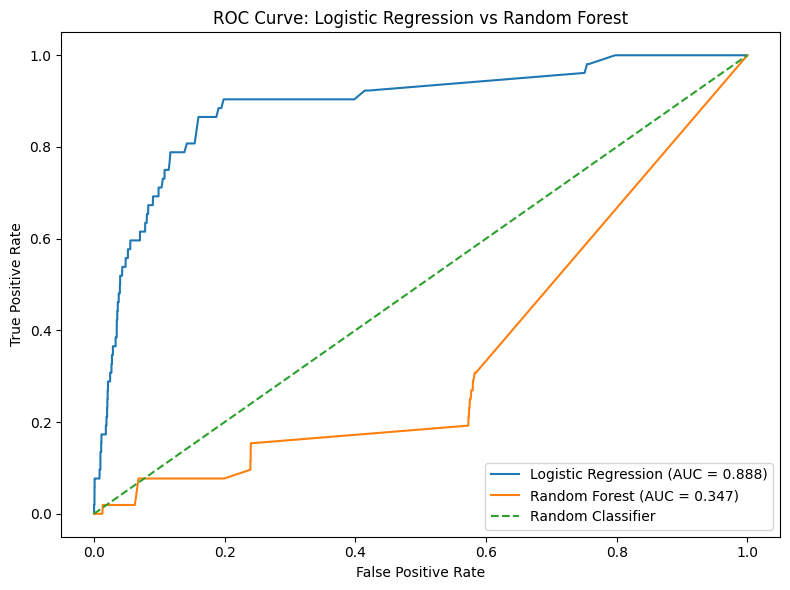

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {logistic_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve: Logistic Regression vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The ROC curve shows a clear difference between the two models.

Logistic Regression performs substantially better than the random-classifier reference line, with a ROC-AUC of **0.888**. This indicates strong ability to rank future purchasers above non-purchasers.

Random Forest performs poorly, with a ROC-AUC of only **0.347**, and much of its curve falls below the random-classifier line. This confirms that Random Forest is not effective for this dataset and feature set.

The ROC analysis therefore supports selecting **Logistic Regression as the final model**.

# 11. Final Model Interpretation

## 11.1 Final Model Selection

Logistic Regression was selected as the final predictive model because it substantially outperformed Random Forest across all evaluation metrics.

The final model achieved a **ROC-AUC of 0.888**, **recall of 63.46%**, and **PR-AUC of 0.0197**. These results indicate that the model has useful ability to rank users according to their likelihood of making a future purchase.

However, precision remains low at **1.18%** because future purchases are extremely rare in the dataset. Therefore, the model should not be treated as a definitive yes-or-no predictor of whether an individual user will purchase.

Instead, the model is better suited as a **customer prioritization tool**, helping identify groups of users with relatively higher purchase potential for further analysis or targeted marketing.

## 11.2 Logistic Regression Feature Interpretation

The final Logistic Regression model uses three earlier-period behavioral features:

- Engagement events
- Page views
- Product views

Because the features were standardized before model training, their coefficients can be compared to understand their relative relationship with predicted future purchase probability.

A positive coefficient indicates that higher values of the feature are associated with a higher predicted probability of future purchase, while a negative coefficient indicates the opposite relationship.

In [32]:
import numpy as np
import pandas as pd

logistic_coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": logistic_model.named_steps["logistic"].coef_[0]
})

logistic_coefficients["Odds_Ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)

logistic_coefficients = logistic_coefficients.sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)

logistic_coefficients.round(4)

,Feature,Coefficient,Odds_Ratio
0,engagement_events,1.7106,5.5325
1,product_views,0.4622,1.5876
2,page_views,-0.6491,0.5225


## 11.3 Feature Coefficient Interpretation

The Logistic Regression coefficients provide insight into how each standardized engagement feature is associated with future purchase predictions while holding the other features constant.

**Engagement events** have the strongest positive coefficient (**1.7106**) and an odds ratio of **5.5325**. This indicates that higher engagement activity is strongly associated with higher predicted odds of a future purchase.

**Product views** also have a positive coefficient (**0.4622**) and an odds ratio of **1.5876**, suggesting that greater interaction with product pages is associated with higher predicted purchase likelihood.

**Page views** have a negative coefficient (**-0.6491**) and an odds ratio of **0.5225** after controlling for engagement events and product views. This should be interpreted cautiously. Page views overlap with the other engagement measures, so the negative coefficient does not necessarily mean that browsing more pages causes users to become less likely to purchase.

Because the predictors were standardized, the odds ratios correspond approximately to a one-standard-deviation increase in each feature while the other features are held constant.

Overall, **engagement events appear to be the strongest positive predictor in the final model**, followed by product views.

# 12. Business Recommendations and Conclusion

## 12.1 Key Business Findings

The GA4 ecommerce analysis identified several important patterns across the customer journey.

1. **The ecommerce funnel shows substantial drop-off.** At the event level, only 15.16% of product-view events progressed to add-to-cart events, while only 14.69% of checkout events corresponded to purchase events. These stages represent important areas for further investigation.

2. **Device category has little practical relationship with purchase activity.** Although the chi-square test found a statistically significant association between device category and purchase activity, Cramér's V was only 0.0047, indicating a negligible practical relationship.

3. **Traffic source provides a stronger segmentation signal than device category.** Traffic source was statistically associated with purchase activity, but its Cramér's V of 0.0318 still indicates a weak relationship. Traffic source may therefore contribute to customer segmentation, but it should not be used as the sole basis for targeting decisions.

4. **User engagement is strongly associated with purchase behavior.** Purchasers showed substantially higher engagement events, page views, and product views than non-purchasers in the descriptive analysis.

5. **Earlier engagement behavior contains useful information for predicting future purchases.** Logistic Regression achieved a ROC-AUC of 0.888 and recall of 63.46%, substantially outperforming Random Forest.

6. **Engagement events were the strongest positive predictor in the final Logistic Regression model**, followed by product views.

## 12.2 Business Recommendations

Based on the analysis, the following actions are recommended:

**Investigate major funnel drop-off points.** The business should examine why product-view activity does not consistently progress to cart activity and why many checkout events do not result in purchase events. Additional session- or user-level analysis could help identify possible sources of friction.

**Prioritize highly engaged users for marketing analysis.** Engagement events and product views were positively associated with future purchase predictions. These behavioral signals could help identify higher-potential audiences for remarketing or personalized campaigns.

**Use the Logistic Regression model as a prioritization tool rather than a definitive purchase predictor.** The model has strong ranking ability but low precision because purchases are extremely rare. It is therefore better suited for ranking or segmenting users for further targeting than making definitive individual purchase predictions.

**Use traffic source as a supporting segmentation variable.** Traffic source showed a stronger relationship with purchase activity than device category, although the practical effect remained weak.

**Test marketing interventions experimentally.** Predictive results identify patterns and potential audiences but do not establish causation. A/B testing should be used to determine whether targeted campaigns, checkout improvements, or other interventions actually increase conversions.

## 12.3 Limitations

This project uses the public, obfuscated Google Analytics 4 ecommerce sample covering approximately three months from November 2020 through January 2021. Results may therefore not represent current customer behavior or other ecommerce businesses.

The funnel and device/traffic-source analyses are based primarily on aggregate event counts rather than complete user-level conversion journeys. Funnel percentages should therefore be interpreted as event-level progression indicators rather than exact customer conversion probabilities.

The exploratory chi-square analyses also use repeated event-level observations, which may not fully satisfy the statistical assumption of independent observations.

The predictive model uses only three behavioral features: engagement events, page views, and product views. Additional information could potentially improve model performance.

Although the model separates earlier behavioral features from future purchase outcomes to reduce leakage, the train/test split is performed across users from the same feature and prediction periods rather than using a complete forward-in-time validation design.

Finally, the analysis identifies associations and predictive relationships, not causal effects.

## 12.4 Conclusion

This project demonstrates an end-to-end ecommerce analytics workflow using BigQuery, SQL, Python, statistical testing, and machine learning.

The analysis found substantial event-level drop-off within the ecommerce funnel, limited practical differences across device categories, weak but measurable differences across traffic sources, and a strong relationship between user engagement and purchase behavior.

For future purchase prediction, Logistic Regression substantially outperformed Random Forest and achieved a ROC-AUC of 0.888 with 63.46% recall. Because purchases are extremely rare and model precision remains low, the model is most useful for prioritizing higher-potential users rather than making definitive purchase predictions.

Overall, the results suggest that customer engagement behavior provides more useful predictive information than device category alone. Future work should combine richer behavioral features, user- or session-level funnel analysis, stronger temporal validation, and controlled A/B testing to determine which business interventions actually improve ecommerce conversion.